# TFT (Temporal Fusion Transformer) — Google Colab
**데이터 경로**: `/content/drive/MyDrive/tft_data/final_dataset_tft_ready.csv`  
**출력 경로**: `/content/drive/MyDrive/tft_outputs/`

## 1. Google Drive 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. 패키지 설치

In [2]:
!pip install pytorch-forecasting lightning yfinance -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.4/848.4 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 32.0 MB/s eta 0:00:00


## 3. Config

In [7]:
import torch
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

import os

# ── 경로 ──────────────────────────────────────────────────────────────────────
RAW_DATA_PATH       = "/content/drive/MyDrive/tft_data/final_dataset_tft_ready.csv"
PROCESSED_DATA_PATH = "/content/drive/MyDrive/tft_outputs/final_dataset_preprocessed.csv"
SCALER_DIR          = "/content/drive/MyDrive/tft_outputs/scalers"
CHECKPOINT_DIR      = "/content/drive/MyDrive/tft_outputs/checkpoints"
LOG_DIR             = "/content/drive/MyDrive/tft_outputs/logs"

for _d in [SCALER_DIR, CHECKPOINT_DIR, LOG_DIR,
           os.path.dirname(PROCESSED_DATA_PATH)]:
    os.makedirs(_d, exist_ok=True)

# ── Train/Val Split ────────────────────────────────────────────────────────────
# target_5d(t) = log(end_{t+5} / end_t) 이므로 train 마지막 row의 target이
# validation 구간 가격을 참조하지 않도록 두 날짜를 분리.
TRAIN_END_DATE = "2024-07-23"   # train feature row 마지막 날짜
VAL_START_DATE = "2024-07-30"   # validation prediction 시작 날짜

# ── 컬럼 정의 ──────────────────────────────────────────────────────────────────
TARGET_COL   = "target_5d"
GROUP_COL    = "ticker"
SECTOR_COL   = "sector"
TIME_IDX_COL = "time_idx"

LOG1P_COLS = ["AUM", "domestic_count", "global_count"]

SECTOR_ZSCORE_COLS = [
    "domestic_mean",
    "domestic_std",
    "domestic_count_log",
    "global_mean",
    "global_std",
    "global_count_log",
]

MACRO_SCALE_COLS = ["usd_krw_return_5d", "vix_close", "wti_return_5d", "us10y_change_5d"]

# ── Feature Group 관리 ────────────────────────────────────────────────────────
PRICE_FEATURES     = ["AUM_log"]
SENTIMENT_FEATURES = ["domestic_mean", "domestic_std", "domestic_count_log",
                      "global_mean", "global_std", "global_count_log"]
MACRO_FEATURES     = ["usd_krw_return_5d", "vix_close", "wti_return_5d", "us10y_change_5d"]
ROLLING_FEATURES   = []   # 추후 추가 예정
CALENDAR_KNOWN_REALS          = []   # 추후 추가 예정
CALENDAR_KNOWN_CATEGORICALS   = []   # 추후 추가 예정

#FEATURE_VERSION = "price_macro_sentiment"
FEATURE_VERSION = "no_end_macro_sentiment_wti_rate_fxret"   # ← 실험할 버전 이름으로 변경
FEATURE_MAP = {
    "price":                        PRICE_FEATURES,
    "price_macro":                  PRICE_FEATURES + MACRO_FEATURES,
    "price_sentiment":              PRICE_FEATURES + SENTIMENT_FEATURES,
    "price_macro_sentiment":        PRICE_FEATURES + MACRO_FEATURES + SENTIMENT_FEATURES,
    "price_macro_sentiment_rolling": PRICE_FEATURES + MACRO_FEATURES + SENTIMENT_FEATURES + ROLLING_FEATURES,
    "no_end_macro_sentiment":          PRICE_FEATURES + MACRO_FEATURES + SENTIMENT_FEATURES,
    "no_end_macro_sentiment_wti_rate":       PRICE_FEATURES + MACRO_FEATURES + SENTIMENT_FEATURES,
    "no_end_macro_sentiment_wti_rate_fxret": PRICE_FEATURES + MACRO_FEATURES + SENTIMENT_FEATURES,
}

TIME_VARYING_UNKNOWN_REALS      = FEATURE_MAP[FEATURE_VERSION]
TIME_VARYING_KNOWN_REALS        = CALENDAR_KNOWN_REALS
TIME_VARYING_KNOWN_CATEGORICALS = CALENDAR_KNOWN_CATEGORICALS

# ── 모델 하이퍼파라미터 C ────────────────────────────────────────────────────────
MAX_ENCODER_LENGTH    = 60
MAX_PREDICTION_LENGTH = 1
BATCH_SIZE            = 64
LEARNING_RATE         = 1e-4

HIDDEN_SIZE            = 64
ATTENTION_HEAD_SIZE    = 2
DROPOUT                = 0.2
HIDDEN_CONTINUOUS_SIZE = 32

MAX_EPOCHS = 50
PATIENCE   = 5
gradient_clip_val = 0.5

print(f"Config loaded. FEATURE_VERSION={FEATURE_VERSION}")
print(f"  TIME_VARYING_UNKNOWN_REALS  : {TIME_VARYING_UNKNOWN_REALS}")
print(f"  TIME_VARYING_KNOWN_REALS    : {TIME_VARYING_KNOWN_REALS}")
print(f"  TIME_VARYING_KNOWN_CATEGORICALS: {TIME_VARYING_KNOWN_CATEGORICALS}")

Config loaded. FEATURE_VERSION=no_end_macro_sentiment
  TIME_VARYING_UNKNOWN_REALS  : ['AUM_log', 'usd_krw', 'vix_close', 'domestic_mean', 'domestic_std', 'domestic_count_log', 'global_mean', 'global_std', 'global_count_log']
  TIME_VARYING_KNOWN_REALS    : []
  TIME_VARYING_KNOWN_CATEGORICALS: []


## 4. 전처리 (Preprocessing)

In [8]:
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


def load_and_sort(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    return df


def apply_log1p(df: pd.DataFrame) -> pd.DataFrame:
    for col in LOG1P_COLS:
        df[f"{col}_log"] = np.log1p(df[col])
    return df


def apply_usd_krw_return_5d(df: pd.DataFrame) -> pd.DataFrame:
    """usd_krw 5일 log return을 날짜 수준에서 계산 후 merge."""
    date_fx = (
        df[["date", "usd_krw"]]
        .drop_duplicates("date")
        .sort_values("date")
        .copy()
    )
    date_fx["usd_krw_return_5d"] = np.log(date_fx["usd_krw"] / date_fx["usd_krw"].shift(5))
    date_fx = date_fx[["date", "usd_krw_return_5d"]]
    df = df.merge(date_fx, on="date", how="left")
    return df


def fit_sector_zscore(train_df: pd.DataFrame) -> dict:
    stats = {}
    for col in SECTOR_ZSCORE_COLS:
        stats[col] = {}
        for sector, grp in train_df.groupby(SECTOR_COL):
            m = grp[col].mean()
            s = grp[col].std()
            s = s if s > 0 else 1.0
            stats[col][sector] = {"mean": m, "std": s}
    return stats


def apply_sector_zscore(df: pd.DataFrame, stats: dict) -> pd.DataFrame:
    for col, sector_stats in stats.items():
        def _zscore(row, _stats=sector_stats):
            s = _stats.get(row[SECTOR_COL])
            if s is None:
                return row[col]
            return (row[col] - s["mean"]) / s["std"]
        df[col] = df.apply(_zscore, axis=1)
    return df


def fit_macro_scaler(train_df: pd.DataFrame) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(train_df[MACRO_SCALE_COLS])
    return scaler


def apply_macro_scaler(df: pd.DataFrame, scaler: StandardScaler) -> pd.DataFrame:
    df[MACRO_SCALE_COLS] = scaler.transform(df[MACRO_SCALE_COLS])
    return df


def save_scalers(stats: dict, macro_scaler: StandardScaler, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)
    with open(os.path.join(out_dir, "sector_zscore_stats.pkl"), "wb") as f:
        pickle.dump(stats, f)
    with open(os.path.join(out_dir, "macro_scaler.pkl"), "wb") as f:
        pickle.dump(macro_scaler, f)
    print(f"Scalers saved → {out_dir}")


print("Preprocessing functions defined.")

Preprocessing functions defined.


In [ ]:
print("Loading data...")
df_raw = load_and_sort(RAW_DATA_PATH)
print(f"  Shape: {df_raw.shape}")

# ── WTI(CL=F), 미국 10년 금리(^TNX) — 5일 변화율 ────────────────────────
import yfinance as yf

_data_start = df_raw["date"].min().strftime("%Y-%m-%d")
_data_end   = (df_raw["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

def _get_close_series(ticker, start, end):
    """yfinance 다운로드 → Close Series (MultiIndex 컬럼 대응)."""
    raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    if raw.empty:
        return None
    col = raw["Close"] if "Close" in raw.columns else raw.iloc[:, 0]
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]
    col.index = pd.to_datetime(col.index)
    return col

_wti_s = _get_close_series("CL=F", _data_start, _data_end)
_tnx_s = _get_close_series("^TNX", _data_start, _data_end)

# WTI: log return (가격 → 수익률), US10Y: 단순 차분 (금리 → bp 변화)
_wti_df = pd.DataFrame({
    "date":          pd.to_datetime(_wti_s.index),
    "wti_return_5d": np.log(_wti_s / _wti_s.shift(5)).values,
})
_tnx_df = pd.DataFrame({
    "date":             pd.to_datetime(_tnx_s.index),
    "us10y_change_5d":  (_tnx_s - _tnx_s.shift(5)).values,
})

_macro_ext = (
    _wti_df
    .merge(_tnx_df, on="date", how="outer")
    .sort_values("date")
    .reset_index(drop=True)
)

df_raw = df_raw.merge(_macro_ext, on="date", how="left")
print(f"  매크로 변화율 조인 — NaN: "
      f"wti={df_raw['wti_return_5d'].isna().sum()}, "
      f"us10y={df_raw['us10y_change_5d'].isna().sum()}")

date_macro = df_raw[["date", "wti_return_5d", "us10y_change_5d"]].drop_duplicates("date").sort_values("date")
for col in ["wti_return_5d", "us10y_change_5d"]:
    date_macro[col] = date_macro[col].ffill(limit=1)
df_raw = df_raw.drop(columns=["wti_return_5d", "us10y_change_5d"])
df_raw = df_raw.merge(date_macro, on="date", how="left")
print(f"ffill 후 NaN — wti: {df_raw['wti_return_5d'].isna().sum()}, us10y: {df_raw['us10y_change_5d'].isna().sum()}")
# ─────────────────────────────────────────────────────────────────────────



print("Computing usd_krw 5일 log return...")
df_raw = apply_usd_krw_return_5d(df_raw)
print(f"  usd_krw_return_5d NaN: {df_raw['usd_krw_return_5d'].isna().sum()}")

print("Applying log1p...")
df_raw = apply_log1p(df_raw)

train_mask = df_raw["date"] <= pd.Timestamp(TRAIN_END_DATE)
train_df_fit = df_raw[train_mask]
print(f"  Train rows: {train_mask.sum()}, Val rows: {(~train_mask).sum()}")

print("Fitting sector z-score (train only)...")
sector_stats = fit_sector_zscore(train_df_fit)
df_raw = apply_sector_zscore(df_raw, sector_stats)

print("Fitting macro StandardScaler (train only)...")
macro_scaler = fit_macro_scaler(train_df_fit)
df_raw = apply_macro_scaler(df_raw, macro_scaler)

df_raw = df_raw.drop(columns=LOG1P_COLS)

os.makedirs(os.path.dirname(PROCESSED_DATA_PATH), exist_ok=True)
df_raw.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Preprocessed data saved → {PROCESSED_DATA_PATH}")

save_scalers(sector_stats, macro_scaler, SCALER_DIR)

print("\n── Sanity Check ──")
print(f"  Columns: {list(df_raw.columns)}")
nan_counts = df_raw.isnull().sum()
print(f"  NaN:\n{nan_counts[nan_counts > 0]}")
val_df_check = df_raw[~train_mask.values]
print(f"  Val date range: {val_df_check['date'].min().date()} ~ {val_df_check['date'].max().date()}")

Loading data...
  Shape: (41840, 16)
Applying log1p...
  Train rows: 31778, Val rows: 10062
Fitting sector z-score (train only)...
Fitting macro StandardScaler (train only)...
Preprocessed data saved → /content/drive/MyDrive/tft_outputs/final_dataset_preprocessed.csv
Scalers saved → /content/drive/MyDrive/tft_outputs/scalers

── Sanity Check ──
  Columns: ['date', 'ticker', 'name', 'end', 'target_5d', 'sector', 'domestic_mean', 'domestic_std', 'global_mean', 'global_std', 'usd_krw', 'vix_close', 'time_idx', 'AUM_log', 'domestic_count_log', 'global_count_log']
  NaN:
target_5d    115
dtype: int64
  Val date range: 2024-07-24 ~ 2025-12-30


## 5. Dataset & DataLoader

In [10]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

STATIC_CATEGORICALS = [GROUP_COL, SECTOR_COL]  # ticker, sector


def load_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, parse_dates=["date"])
    df = df.dropna(subset=[TARGET_COL, "wti_return_5d", "us10y_change_5d", "usd_krw_return_5d"]).reset_index(drop=True)
    for col in STATIC_CATEGORICALS:
        df[col] = df[col].astype(str)
    df = df.sort_values([GROUP_COL, "date"]).reset_index(drop=True)
    return df


def make_datasets(csv_path: str = PROCESSED_DATA_PATH, batch_size: int = BATCH_SIZE):
    df = load_data(csv_path)

    train_df = df[df["date"] <= pd.Timestamp(TRAIN_END_DATE)].copy()
    val_min_idx = df.loc[df["date"] >= pd.Timestamp(VAL_START_DATE), TIME_IDX_COL].min()

    print("\n── Dataset Split Check ──")
    print(f"  Train date range : {train_df['date'].min().date()} ~ {train_df['date'].max().date()}")
    val_df_check = df[df[TIME_IDX_COL] >= val_min_idx]
    print(f"  Val date range   : {val_df_check['date'].min().date()} ~ {val_df_check['date'].max().date()}")
    print(f"  val_min_idx      : {val_min_idx}")

    train_ds = TimeSeriesDataSet(
        train_df,
        time_idx=TIME_IDX_COL,
        target=TARGET_COL,
        group_ids=[GROUP_COL],
        max_encoder_length=MAX_ENCODER_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=STATIC_CATEGORICALS,
        static_reals=[],
        time_varying_known_categoricals=TIME_VARYING_KNOWN_CATEGORICALS,
        time_varying_known_reals=TIME_VARYING_KNOWN_REALS,
        time_varying_unknown_reals=TIME_VARYING_UNKNOWN_REALS,
        target_normalizer=GroupNormalizer(
            groups=[GROUP_COL],
            transformation=None,
        ),
        scalers={
            #"end": GroupNormalizer(groups=[GROUP_COL], transformation=None),
            "AUM_log": GroupNormalizer(groups=[GROUP_COL], transformation=None),
        },
        allow_missing_timesteps=True,
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    val_ds = TimeSeriesDataSet.from_dataset(
        train_ds,
        df,
        predict=False,
        stop_randomization=True,
        min_prediction_idx=val_min_idx,
    )

    train_loader = train_ds.to_dataloader(train=True, batch_size=batch_size, num_workers=2)
    val_loader   = val_ds.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=2)

    return train_ds, val_ds, train_loader, val_loader


print("Dataset functions defined.")

Dataset functions defined.


In [11]:
train_ds, val_ds, train_loader, val_loader = make_datasets()

print(f"Train samples : {len(train_ds)}")
print(f"Val   samples : {len(val_ds)}")

x, y = next(iter(train_loader))
print(f"Batch x keys  : {list(x.keys())}")
print(f"Batch y shape : {y[0].shape}")


── Dataset Split Check ──
  Train date range : 2019-01-02 ~ 2024-07-23
  Val date range   : 2024-07-30 ~ 2025-12-22
  val_min_idx      : 1375
Train samples : 30038
Val   samples : 9831
Batch x keys  : ['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale']
Batch y shape : torch.Size([64, 1])


## 6. 모델 & Trainer 정의

In [12]:
import lightning as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import MAE, RMSE, QuantileLoss

QUANTILES = [0.1, 0.5, 0.9]


def build_model(train_ds) -> TemporalFusionTransformer:
    model = TemporalFusionTransformer.from_dataset(
        train_ds,
        hidden_size=HIDDEN_SIZE,
        attention_head_size=ATTENTION_HEAD_SIZE,
        dropout=DROPOUT,
        hidden_continuous_size=HIDDEN_CONTINUOUS_SIZE,
        loss=QuantileLoss(quantiles=QUANTILES),
        logging_metrics=[MAE(), RMSE()],
        learning_rate=LEARNING_RATE,
        optimizer="adam",
        log_interval=10,
        log_val_interval=1,
    )
    return model




def build_trainer(max_epochs: int = MAX_EPOCHS, logger_name: str = None, gradient_clip_val: float = 0.1, min_epochs: int = 10) -> pl.Trainer:
    ckpt_subdir = logger_name if logger_name is not None else FEATURE_VERSION
    early_stop = EarlyStopping(
        monitor="val_loss",
        min_delta=1e-5,
        patience=PATIENCE,
        mode="min",
        verbose=True,
    )
    checkpoint = ModelCheckpoint(
        dirpath=os.path.join(CHECKPOINT_DIR, ckpt_subdir),
        filename=f"tft-{ckpt_subdir}-{{epoch:02d}}-{{val_loss:.4f}}",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )
    _logger_name = logger_name if logger_name is not None else FEATURE_VERSION
    logger = CSVLogger(save_dir=LOG_DIR, name=_logger_name)

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        min_epochs=min_epochs,
        accelerator="auto",
        gradient_clip_val=gradient_clip_val,
        callbacks=[early_stop, checkpoint],
        logger=logger,
        enable_progress_bar=True,
        deterministic=False,
    )
    return trainer


print("Model / Trainer functions defined.")

Model / Trainer functions defined.


## 7. 학습 실행

In [13]:
print("=" * 60)
print("Building model...")
model = build_model(train_ds)
print(f"  Parameters : {sum(p.numel() for p in model.parameters()):,}")

print("\nBuilding trainer...")
trainer = build_trainer(max_epochs=MAX_EPOCHS, gradient_clip_val=gradient_clip_val)

print("\nTraining...")
print("=" * 60)
trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

print("=" * 60)
print("Training complete.")
best_ckpt = trainer.checkpoint_callback.best_model_path
print(f"  Best checkpoint : {best_ckpt}")
print(f"  Best val_loss   : {trainer.checkpoint_callback.best_model_score:.6f}")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightn

Building model...
  Parameters : 308,957

Building trainer...

Training...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    391 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    832 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 21.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 71.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  6.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 12.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    195 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 308 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 308 K                                                                                                
Total estimated model params size (MB): 1.236                                                                      
Modules in train mode: 359                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: Metric val_loss improved. New best score: 0.013
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.013
INFO: Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.013
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.013
INFO: Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.013
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.013
INFO: Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.012
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.012
INFO: Monitored metric val_loss did not improve in the last 5 records. Best score: 0.012. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5

Training complete.
  Best checkpoint : /content/drive/MyDrive/tft_outputs/checkpoints/no_end_macro_sentiment/tft-no_end_macro_sentiment-epoch=06-val_loss=0.0125.ckpt
  Best val_loss   : 0.012455


## 8. 학습 결과 확인

 epoch  step  train_loss_epoch  train_loss_step  val_MAE  val_RMSE  val_loss
    10  4799               NaN         0.010164      NaN       NaN       NaN
    10  4849               NaN         0.009279      NaN       NaN       NaN
    10  4899               NaN         0.013590      NaN       NaN       NaN
    10  4949               NaN         0.008160      NaN       NaN       NaN
    10  4999               NaN         0.009752      NaN       NaN       NaN
    10  5049               NaN         0.012552      NaN       NaN       NaN
    10  5099               NaN         0.011074      NaN       NaN       NaN
    10  5149               NaN         0.010828      NaN       NaN       NaN
    10  5158               NaN              NaN 0.019244  0.026069  0.012707
    10  5158          0.011766              NaN      NaN       NaN       NaN


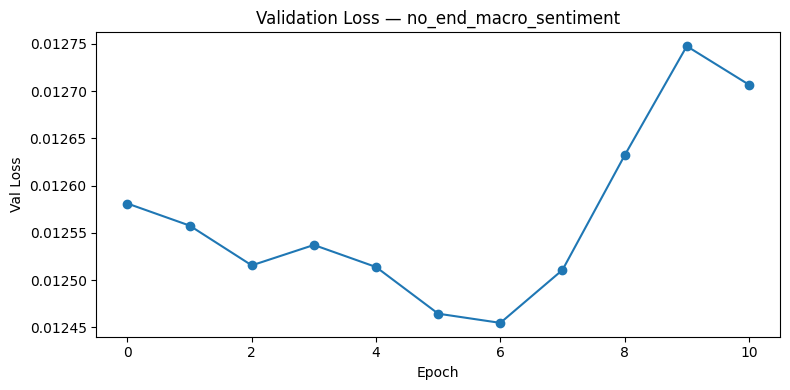

In [14]:
import matplotlib.pyplot as plt

metrics_path = os.path.join(trainer.logger.log_dir, "metrics.csv")
if os.path.exists(metrics_path):
    metrics = pd.read_csv(metrics_path)
    print(metrics.tail(10).to_string(index=False))

    val_loss = metrics.dropna(subset=["val_loss"])
    if not val_loss.empty:
        plt.figure(figsize=(8, 4))
        plt.plot(val_loss["epoch"], val_loss["val_loss"], marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Val Loss")
        plt.title(f"Validation Loss — {FEATURE_VERSION}")
        plt.tight_layout()
        plt.savefig(os.path.join(trainer.logger.log_dir, "val_loss.png"), dpi=120)
        plt.show()
else:
    print(f"metrics.csv not found at {metrics_path}")

## 9. 실험 결과 누적 저장

In [ ]:
import matplotlib.pyplot as plt

# 예전 ckpt로 로드 (성능 더 좋은 거)
ckpt_path = "/content/drive/MyDrive/tft_outputs/checkpoints/price_macro_sentiment/tft-price_macro_sentiment-epoch=05-val_loss=0.0126.ckpt"
model_vsn = TemporalFusionTransformer.load_from_checkpoint(ckpt_path)
model_vsn.eval()



/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


TemporalFusionTransformer(
  	"attention_head_size":               2
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'target_5d', 'group_ids': ['ticker'], 'weight': None, 'max_encoder_length': 60, 'min_encoder_length': 60, 'min_prediction_idx': 0, 'min_prediction_length': 1, 'max_prediction_length': 1, 'static_categoricals': ['ticker', 'sector'], 'static_reals': [], 'time_varying_known_categoricals': [], 'time_varying_known_reals': [], 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['end', 'AUM_log', 'usd_krw', 'vix_close', 'domestic_mean', 'domestic_std', 'domestic_count_log', 'global_mean', 'global_std', 'global_count_log'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': True, 'lags': None, 'add_relative_time_idx': True, 'add_target_scales': True, 'add_encoder_length': True, 'target_normalizer': GroupNormaliz

In [ ]:
SUMMARY_PATH = "/content/drive/MyDrive/tft_outputs/experiment_summary.csv"

# metrics.csv에서 val_loss 최솟값 row 기준으로 MAE/RMSE 추출
best_val_loss = float(trainer.checkpoint_callback.best_model_score)
best_val_MAE  = None
best_val_RMSE = None
if os.path.exists(metrics_path):
    metrics_df = pd.read_csv(metrics_path)
    _val = metrics_df.dropna(subset=["val_loss"]).copy()
    if not _val.empty:
        best_row = _val.loc[_val["val_loss"].idxmin()]
        best_val_loss = float(best_row["val_loss"])
        best_val_MAE  = float(best_row["val_MAE"])  if "val_MAE"  in best_row and pd.notna(best_row["val_MAE"])  else None
        best_val_RMSE = float(best_row["val_RMSE"]) if "val_RMSE" in best_row and pd.notna(best_row["val_RMSE"]) else None

row = {
    "timestamp":              pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
    "feature_version":        FEATURE_VERSION,
    "train_end_date":         TRAIN_END_DATE,
    "val_start_date":         VAL_START_DATE,
    "target_col":             TARGET_COL,
    "max_encoder_length":     MAX_ENCODER_LENGTH,
    "max_prediction_length":  MAX_PREDICTION_LENGTH,
    "hidden_size":            HIDDEN_SIZE,
    "hidden_continuous_size": HIDDEN_CONTINUOUS_SIZE,
    "attention_head_size":    ATTENTION_HEAD_SIZE,
    "dropout":                DROPOUT,
    "learning_rate":          LEARNING_RATE,
    "batch_size":             BATCH_SIZE,
    "unknown_reals":          "|".join(TIME_VARYING_UNKNOWN_REALS),
    "known_reals":            "|".join(TIME_VARYING_KNOWN_REALS),
    "known_categoricals":     "|".join(TIME_VARYING_KNOWN_CATEGORICALS),
    "best_val_loss":          best_val_loss,
    "best_val_MAE":           best_val_MAE,
    "best_val_RMSE":          best_val_RMSE,
    "best_checkpoint":        trainer.checkpoint_callback.best_model_path,
    "log_dir":                trainer.logger.log_dir,
}

new_row_df = pd.DataFrame([row])
if os.path.exists(SUMMARY_PATH):
    summary = pd.concat([pd.read_csv(SUMMARY_PATH), new_row_df], ignore_index=True)
else:
    summary = new_row_df

summary.to_csv(SUMMARY_PATH, index=False)
print(f"Experiment summary saved → {SUMMARY_PATH}")
print(new_row_df.T.to_string(header=False))

Experiment summary saved → /content/drive/MyDrive/tft_outputs/experiment_summary.csv
timestamp                                                                                                                        2026-05-23 07:02:09
feature_version                                                                                                                price_macro_sentiment
train_end_date                                                                                                                            2024-07-23
val_start_date                                                                                                                            2024-07-30
target_col                                                                                                                                 target_5d
max_encoder_length                                                                                                                                60
max_prediction_length

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

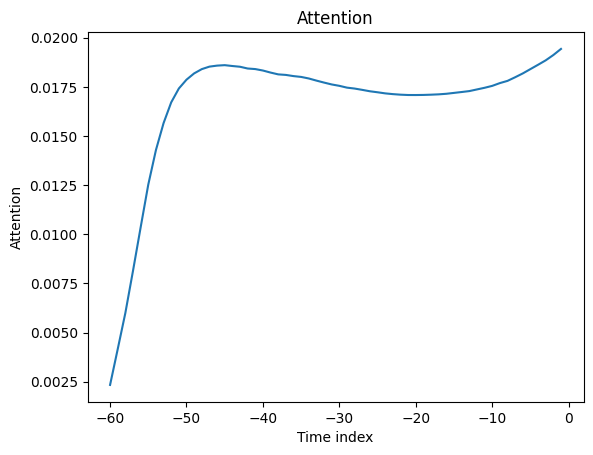

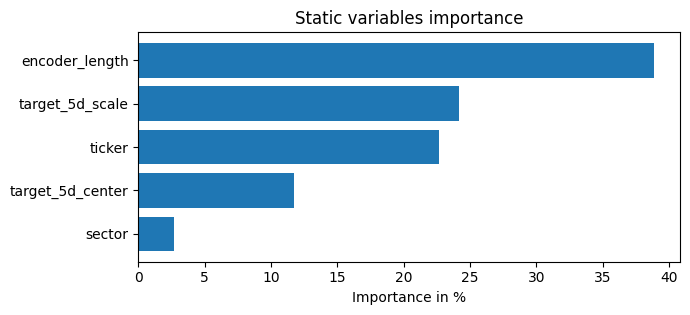

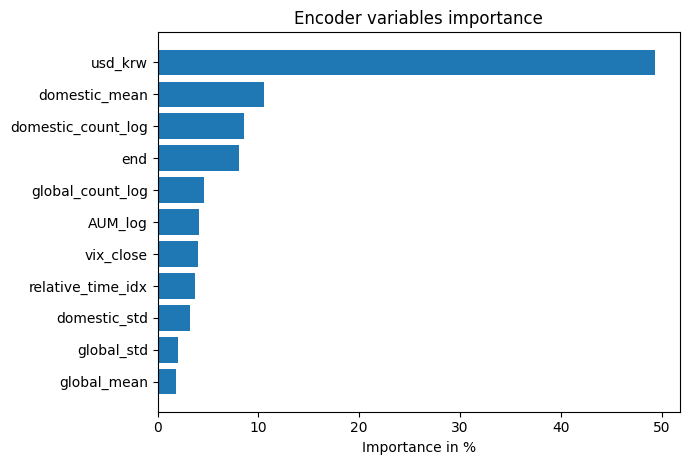

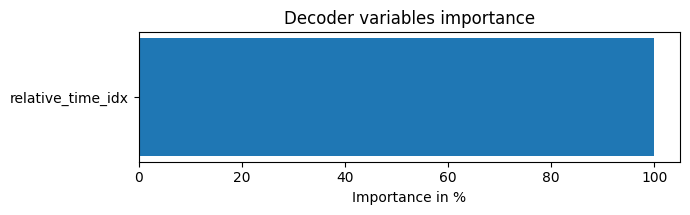

── Encoder Variable Importance ──
  relative_time_idx             : 4851.5244
  AUM_log                       : 1034.7305
  vix_close                     : 841.7698
  target_5d_center              : 796.4014
  domestic_count_log            : 449.0495
  target_5d_scale               : 403.7286
  end                           : 391.5178
  encoder_length                : 368.6732
  usd_krw                       : 319.2310
  domestic_std                  : 194.5695
  domestic_mean                 : 179.8045


In [ ]:
# val_loader로 interpretation 뽑기
output = model_vsn.predict(val_loader, mode="raw", return_x=True)
raw_predictions = output.output
x = output.x

interpretation = model_vsn.interpret_output(raw_predictions, reduction="mean")

# feature importance 시각화
fig = model_vsn.plot_interpretation(interpretation)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/tft_outputs/vsn_importance.png", dpi=120)
plt.show()

print("── Encoder Variable Importance ──")
enc_imp = interpretation["encoder_variables"]
feature_names = train_ds.reals  # encoder에 들어간 feature 이름들

for name, score in sorted(zip(feature_names, enc_imp.tolist()), key=lambda x: x[1], reverse=True):
    print(f"  {name:30s}: {score:.4f}")